# Clustering -  Mental Health 2026

1. Preparación de datos: variables numéricas se deben normalizar y variables categóricas se crean dummies
2. Aprendizaje del Modelo: Kmeans, método del codo
3. Evaluación del Modelo: Inertia, silueta
4. Perfilamiento: Descripción de centroides



In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos

* Previa limpieza de atípicos, nulos y altas correlaciones









In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Se cargan los datos
df = pd.read_csv("mental_health_final_project_2026.csv") #Cargar datos en excel
df.head() #muestras los 5 primeros registros

,tipo_caso,sexo,edad_paciente,reg_seg_social,estado_civil,escolaridad,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,...,elemt_cortop,arm_fuego,inmolac,lanz_vacio,intoxicacion,lanz_vehic,lanz_cuerp_agua,mec_no_ident,tipo_sust,num_intentos
0,Intento,M,31,C,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,2
1,Intento,M,31,C,1,13,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1
2,Intento,M,31,C,1,14,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1
3,Intento,M,31,E,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1
4,Intento,M,31,C,1,14,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1


In [ ]:
#Se revisan los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2301 entries, 0 to 2300
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   tipo_caso              2301 non-null   object
 1   sexo                   2301 non-null   object
 2   edad_paciente          2301 non-null   int64 
 3   reg_seg_social         2301 non-null   object
 4   estado_civil           2301 non-null   int64 
 5   escolaridad            2301 non-null   int64 
 6   conflict_pareja_ex     2301 non-null   int64 
 7   enf_cron_dol_disc      2301 non-null   int64 
 8   probl_econ             2301 non-null   int64 
 9   muerte_fam             2301 non-null   int64 
 10  probl_educ             2301 non-null   int64 
 11  probl_jurid            2301 non-null   int64 
 12  suic_fam_amig          2301 non-null   int64 
 13  maltrato_fis_psic_sex  2301 non-null   int64 
 14  probl_lab              2301 non-null   int64 
 15  probl_fam            

* Transformaciones: normalizar y crear dummies

  **Variables numéricas:** edad_paciente

  **Variables categóricas:** tipo_caso, sexo, reg_seg_social, estado civil, escolaridad, conflict_pareja_ex, enf_cron_dol_disc, probl_econ, muerte_fam, probl_educ, probl_jurid, suic_fam_amig, maltrato_fis_psic_sex, probl_lab, probl_fam, fact_des_no_ident, consum_spa, ant_fam_cond_suic, ideac_suic_persist, plan_org_suic, ant_trast_psiq, trast_depr, trast_person, trast_bip, esquizof, ant_viol_abus, abuso_alcoh, fact_riesg_no_ident, ahorc_asfx, elemt_cortop, arm_fuego, inmolac, lanz_vacio, intoxicacion, lanz_vehic, lanz_cuerp_agua, mec_no_ident, tipo_sust

  **variable objetivo:** num_intentos (numérica)

In [ ]:
#Corregir tipos de datos
df['tipo_caso']=df['tipo_caso'].astype('category')
df['sexo']=df['sexo'].astype('category')
df['reg_seg_social']=df['reg_seg_social'].astype('category')
df['estado_civil']=df['estado_civil'].astype('category')
df['escolaridad']=df['escolaridad'].astype('category')
df['conflict_pareja_ex']=df['conflict_pareja_ex'].astype('category')
df['enf_cron_dol_disc']=df['enf_cron_dol_disc'].astype('category')
df['probl_econ']=df['probl_econ'].astype('category')
df['muerte_fam']=df['muerte_fam'].astype('category')
df['probl_educ']=df['probl_educ'].astype('category')
df['probl_jurid']=df['probl_jurid'].astype('category')
df['suic_fam_amig']=df['suic_fam_amig'].astype('category')
df['maltrato_fis_psic_sex']=df['maltrato_fis_psic_sex'].astype('category')
df['probl_lab']=df['probl_lab'].astype('category')
df['probl_fam']=df['probl_fam'].astype('category')
df['fact_des_no_ident']=df['fact_des_no_ident'].astype('category')
df['consum_spa']=df['consum_spa'].astype('category')
df['ant_fam_cond_suic']=df['ant_fam_cond_suic'].astype('category')
df['ideac_suic_persist']=df['ideac_suic_persist'].astype('category')
df['plan_org_suic']=df['plan_org_suic'].astype('category')
df['ant_trast_psiq']=df['ant_trast_psiq'].astype('category')
df['trast_depr']=df['trast_depr'].astype('category')
df['trast_person']=df['trast_person'].astype('category')
df['trast_bip']=df['trast_bip'].astype('category')
df['esquizof']=df['esquizof'].astype('category')
df['ant_viol_abus']=df['ant_viol_abus'].astype('category')
df['abuso_alcoh']=df['abuso_alcoh'].astype('category')
df['fact_riesg_no_ident']=df['fact_riesg_no_ident'].astype('category')
df['ahorc_asfx']=df['ahorc_asfx'].astype('category')
df['elemt_cortop']=df['elemt_cortop'].astype('category')
df['arm_fuego']=df['arm_fuego'].astype('category')
df['inmolac']=df['inmolac'].astype('category')
df['lanz_vacio']=df['lanz_vacio'].astype('category')
df['intoxicacion']=df['intoxicacion'].astype('category')
df['lanz_vehic']=df['lanz_vehic'].astype('category')
df['lanz_cuerp_agua']=df['lanz_cuerp_agua'].astype('category')
df['mec_no_ident']=df['mec_no_ident'].astype('category')
df['tipo_sust']=df['tipo_sust'].astype('category')

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2301 entries, 0 to 2300
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   tipo_caso              2301 non-null   category
 1   sexo                   2301 non-null   category
 2   edad_paciente          2301 non-null   int64   
 3   reg_seg_social         2301 non-null   category
 4   estado_civil           2301 non-null   category
 5   escolaridad            2301 non-null   category
 6   conflict_pareja_ex     2301 non-null   category
 7   enf_cron_dol_disc      2301 non-null   category
 8   probl_econ             2301 non-null   category
 9   muerte_fam             2301 non-null   category
 10  probl_educ             2301 non-null   category
 11  probl_jurid            2301 non-null   category
 12  suic_fam_amig          2301 non-null   category
 13  maltrato_fis_psic_sex  2301 non-null   category
 14  probl_lab              2301 non-null   c

,tipo_caso,sexo,edad_paciente,reg_seg_social,estado_civil,escolaridad,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,...,elemt_cortop,arm_fuego,inmolac,lanz_vacio,intoxicacion,lanz_vehic,lanz_cuerp_agua,mec_no_ident,tipo_sust,num_intentos
0,Intento,M,31,C,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,2
1,Intento,M,31,C,1,13,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1
2,Intento,M,31,C,1,14,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1
3,Intento,M,31,E,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1
4,Intento,M,31,C,1,14,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1


In [ ]:
#Descripción estadística de variable numéricas
df.describe()

,edad_paciente,num_intentos
count,2301.000000,2301.000000
mean,31.279444,1.239027
std,16.045741,0.659557
min,8.000000,1.000000
25%,19.000000,1.000000
50%,27.000000,1.000000
75%,40.000000,1.000000
max,96.000000,8.000000


array([[<Axes: title={'center': 'edad_paciente'}>,
        <Axes: title={'center': 'num_intentos'}>]], dtype=object)

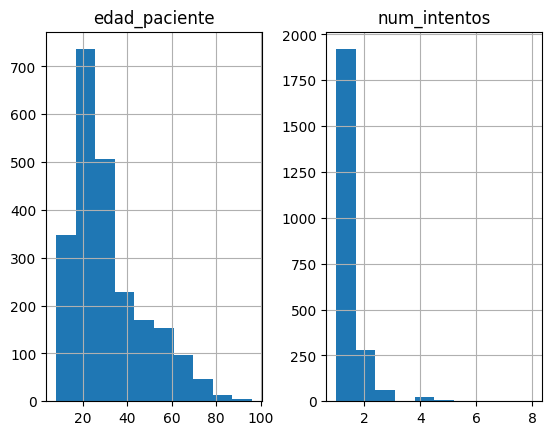

In [ ]:
#Histogramas de las variables numéricas
df.hist()

<Axes: >

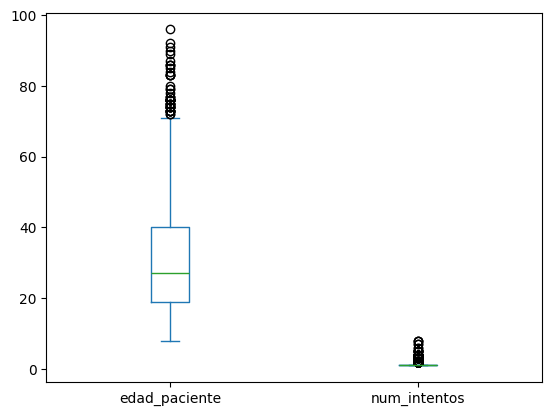

In [ ]:
#Gráfico box para variables numéricas
df.plot(kind='box')

In [ ]:
# Cargar librería para Profiling
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00


In [ ]:
# Perfilado de datos
from ydata_profiling import ProfileReport

profile_data=ProfileReport(df, minimal=True) # minimal=False
profile_data

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 40/40 [00:00<00:00, 114.15it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Copia de los datos
data=df.copy()

In [ ]:
#Normalizacion de variables numéricas

from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
variables_a_normalizar=['edad_paciente', 'num_intentos'] #variables numéricas
min_max_scaler.fit(data[variables_a_normalizar]) #Ajuste de parámetro
data[variables_a_normalizar]= min_max_scaler.transform(data[variables_a_normalizar])
data.head()

,tipo_caso,sexo,edad_paciente,reg_seg_social,estado_civil,escolaridad,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,...,elemt_cortop,arm_fuego,inmolac,lanz_vacio,intoxicacion,lanz_vehic,lanz_cuerp_agua,mec_no_ident,tipo_sust,num_intentos
0,Intento,M,0.261364,C,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0.142857
1,Intento,M,0.261364,C,1,13,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0.000000
2,Intento,M,0.261364,C,1,14,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0.000000
3,Intento,M,0.261364,E,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0.000000
4,Intento,M,0.261364,C,1,14,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0.000000


In [ ]:
# Se crean dummies para las variables categóricas
data = pd.get_dummies(data, columns=['tipo_caso', 'sexo'], drop_first=True, dtype=int) # Se elimina primera columna para variables con solo 2 opciones

data = pd.get_dummies(data, columns=['reg_seg_social', 'estado_civil', 'escolaridad', 'tipo_sust'], drop_first=False, dtype=int) # No se elimina columna para variables con múltiples opciones

data.head()

,edad_paciente,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,probl_educ,probl_jurid,suic_fam_amig,maltrato_fis_psic_sex,probl_lab,...,escolaridad_12,escolaridad_13,escolaridad_14,tipo_sust_1,tipo_sust_2,tipo_sust_3,tipo_sust_5,tipo_sust_6,tipo_sust_7,tipo_sust_8
0,0.261364,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0.261364,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
2,0.261364,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
3,0.261364,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.261364,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


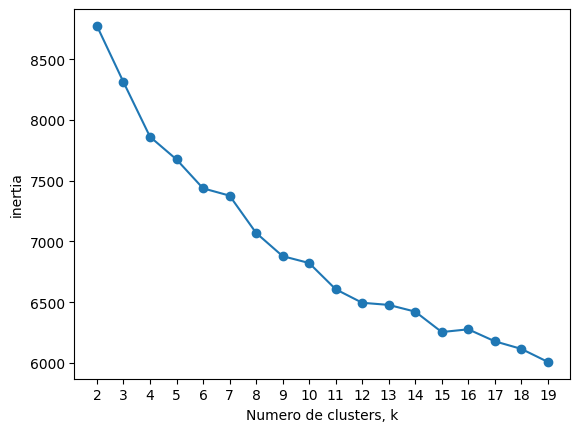

In [ ]:
from sklearn.cluster import KMeans

ks = range(2, 20) # crear valores del 2 al 20
inertias = []

for k in ks:
  # Crear  modelo
  model = KMeans(n_clusters=k,max_iter=300)
  model.fit(data)
  inertias.append(model.inertia_)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)

plt.show()

# 2. Aprendizaje del Modelo
* Metodo del codo
* Aplicar kmeans

In [ ]:
#Creación de modelo de clustering con Kmeans
from sklearn.cluster import KMeans
k=8
model = KMeans(n_clusters=k, max_iter=300)
model.fit(data) #100% datos

KMeans()

# 3. Evaluación del Modelo


*   Inertia: valor pequeño esperado
*   Silueta: valor positivo esperado, idealmente mayor a 0.5



In [ ]:
#Evaluación
from sklearn import metrics

#Inertia: se require valor pequeño
print('Inercia o cohesión:', model.inertia_)

#Silueta: se requiere que sea positivo, ideal 0.5-1.0
sil=metrics.silhouette_score(data, model.labels_)
print('Silueta:',sil)

Inercia o cohesión: 7176.980501248873
Silueta: 0.08620555870475854


In [ ]:
#Centroides almacenados dentro del modelo
model.cluster_centers_

array([[ 2.29215732e-01,  9.22279793e-01,  4.14507772e-02,
         1.45077720e-01,  4.14507772e-02,  5.18134715e-03,
         3.10880829e-02,  5.18134715e-03,  1.03626943e-02,
         5.69948187e-02,  4.14507772e-02, -1.55431223e-15,
         1.24352332e-01,  7.25388601e-02,  2.84974093e-01,
         1.24352332e-01,  1.55440415e-02,  2.07253886e-02,
         0.00000000e+00,  1.03626943e-02,  4.85722573e-17,
         2.07253886e-02,  1.03626943e-01,  4.40414508e-01,
         7.25388601e-02,  1.24352332e-01,  5.18134715e-03,
         5.18134715e-03,  4.14507772e-02,  7.82383420e-01,
         1.55440415e-02,  1.47451495e-17,  5.18134715e-03,
         3.99703923e-02,  1.66533454e-16,  6.73575130e-01,
         8.39378238e-01,  5.18134715e-03,  1.82145965e-17,
         3.62694301e-02,  5.18134715e-03,  1.13989637e-01,
         6.06217617e-01,  1.39896373e-01,  1.86528497e-01,
         2.07253886e-02,  4.66321244e-02,  5.18134715e-03,
         3.62694301e-02,  5.75129534e-01,  7.63278329e-1

In [ ]:
#Centroides de los cluster se convierten  en un dataframe de pandas
centroides=pd.DataFrame(model.cluster_centers_, columns=data.columns.values)
centroides.round(1)

,edad_paciente,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,probl_educ,probl_jurid,suic_fam_amig,maltrato_fis_psic_sex,probl_lab,...,escolaridad_12,escolaridad_13,escolaridad_14,tipo_sust_1,tipo_sust_2,tipo_sust_3,tipo_sust_5,tipo_sust_6,tipo_sust_7,tipo_sust_8
0,0.2,0.9,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.1,...,0.0,0.0,0.1,0.9,0.1,0.0,0.0,0.1,0.0,0.0
1,0.3,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,...,0.0,0.1,0.3,0.0,0.1,-0.0,0.0,0.2,0.1,0.6
2,0.2,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.3,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,...,0.0,0.0,0.3,0.2,0.1,0.0,0.0,0.1,0.0,0.6
4,0.4,0.1,0.1,0.3,0.0,0.0,0.0,0.0,-0.0,0.2,...,0.0,-0.0,0.3,1.0,-0.0,0.0,0.0,0.0,0.0,-0.0
5,0.3,0.6,0.1,0.1,0.1,0.1,0.0,0.0,0.1,0.1,...,0.0,0.0,0.2,0.9,0.1,0.0,0.0,0.1,0.0,-0.0
6,0.2,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,...,-0.0,0.0,0.1,1.0,-0.0,-0.0,-0.0,0.0,0.0,0.0
7,0.2,0.0,0.1,0.2,0.0,0.1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.2,0.9,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Se realiza una des-normalización centroides
centroides[variables_a_normalizar]=min_max_scaler.inverse_transform(centroides[variables_a_normalizar])
centroides.round(0)

,edad_paciente,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,probl_educ,probl_jurid,suic_fam_amig,maltrato_fis_psic_sex,probl_lab,...,escolaridad_12,escolaridad_13,escolaridad_14,tipo_sust_1,tipo_sust_2,tipo_sust_3,tipo_sust_5,tipo_sust_6,tipo_sust_7,tipo_sust_8
0,28.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,36.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1.0
2,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,36.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,...,0.0,-0.0,0.0,1.0,-0.0,0.0,0.0,0.0,0.0,-0.0
5,33.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.0
6,28.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,...,-0.0,0.0,0.0,1.0,-0.0,-0.0,-0.0,0.0,0.0,0.0
7,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# 4. Perfilamiento

Descripción de centroides

**DESCRIPCIÓN DE PERFILES**

PERFIL 0: Edad promedio de 28 años, conflicto con pareja, hombre , intoxicación, consume sustancia 1

PERFIL 1: Edad promedio de 35 años, mujer, factor desconocido no identificado, intoxicación, consume sustancia 8

PERFIL 2: Edad promedio de 23 años, antecedente de trastorno psiquiátrico, trastorno depresivo, hombre, intoxicación, consume sustancia 1

PERFIL 3: Edad promedio de 35 años, factor desconocido no identificado, mujer, intoxicación, consume sustancia 8

PERFIL 4: Edad promedio de 43 años, mujer, consume sustancia 1

PERFIL 5: Edad promedio de 34 años, conflicto con pareja, antecedente de trastorno psiquiátrico, trastorno depresivo, hombre, intoxicación, consume sustancia 1

PERFIL 6: Edad promedio de 28 años, factor desconocido no identificado, hombre, intoxicación, consume sustancia 1

PERFIL 7: Edad promedio de 27 años, mujer, consume sustancia 1

In [ ]:
#En el dataframe original, se adiciona el cluster asignado a cada registro
df['cluster']=model.labels_
df.head()

,tipo_caso,sexo,edad_paciente,reg_seg_social,estado_civil,escolaridad,conflict_pareja_ex,enf_cron_dol_disc,probl_econ,muerte_fam,...,arm_fuego,inmolac,lanz_vacio,intoxicacion,lanz_vehic,lanz_cuerp_agua,mec_no_ident,tipo_sust,num_intentos,cluster
0,Intento,M,31,C,1,1,0,0,0,0,...,0,0,0,1,0,0,0,1,2,6
1,Intento,M,31,C,1,13,0,0,0,0,...,0,0,0,1,0,0,0,1,1,6
2,Intento,M,31,C,1,14,0,0,0,0,...,0,0,0,1,0,0,0,1,1,6
3,Intento,M,31,E,1,1,0,0,0,0,...,0,0,0,1,0,0,0,1,1,6
4,Intento,M,31,C,1,14,0,0,0,0,...,0,0,0,1,0,0,0,1,1,6


<Axes: ylabel='count'>

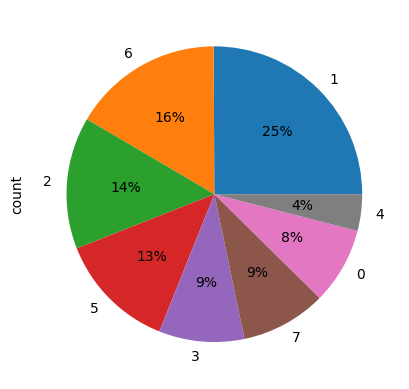

In [ ]:
#Cantidad de datos en cada cluster
df["cluster"].value_counts().plot(kind='pie',autopct='%.0f%%')

In [ ]:
#Almacenar resultados
df.to_excel('./resultados_Kmeans.xlsx')
centroides.to_excel('./centroides.xlsx')